Матрица смежности:
[0, 1, 1, 0, 0, 0, 0]
[1, 0, 1, 0, 0, 0, 0]
[1, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 1, 0, 1, 0]
[0, 0, 0, 0, 1, 0, 1]
[0, 0, 0, 0, 0, 1, 0]

Матрица инцидентности:
[1, 0, 1, 0, 0, 0]
[1, 1, 0, 0, 0, 0]
[0, 1, 1, 0, 0, 0]
[0, 0, 0, 1, 0, 0]
[0, 0, 0, 1, 1, 0]
[0, 0, 0, 0, 1, 1]
[0, 0, 0, 0, 0, 1]

Компоненты связности: [[1, 3, 2], [4, 5, 6, 7]]


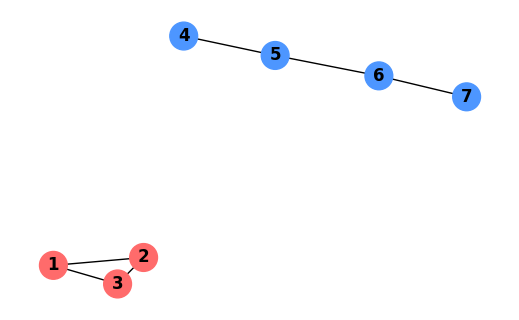


Вставлены элементы: [50, 30, 70, 20, 40, 60, 80]


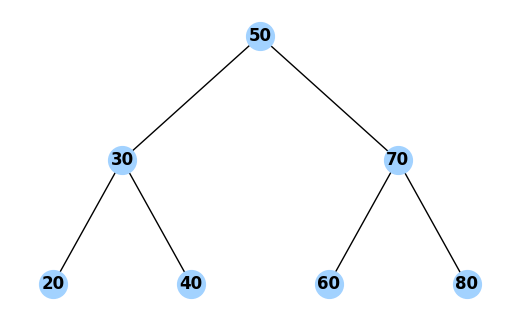

Поиск 40: Найден
Удаляем 30...


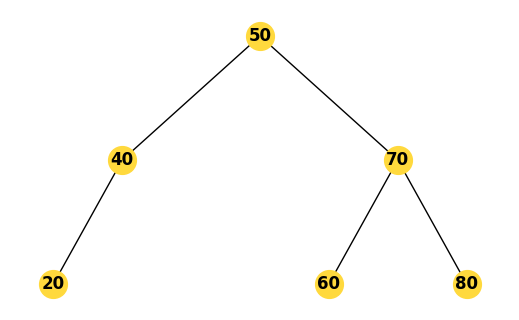


Исходный массив: [50, 30, 70, 20, 40, 60, 80]
Отсортированный массив: [20, 30, 40, 50, 60, 70, 80]


In [13]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx

def matrix_sm(n, edges):
    matrix = [[0]*n for _ in range(n)]
    for a, b in edges:
        matrix[a-1][b-1] = 1
        matrix[b-1][a-1] = 1
    return matrix

def matrix_inc(n, edges):
    matrix = [[0]*len(edges) for _ in range(n)]
    for i in range(len(edges)):
        a, b = edges[i]
        matrix[a-1][i] = 1
        matrix[b-1][i] = 1
    return matrix

def find_components(n, edges):
    adj = [[] for _ in range(n)]
    for a, b in edges:
        adj[a-1].append(b-1)
        adj[b-1].append(a-1)

    visited = [False]*n
    components = []

    for i in range(n):
        if not visited[i]:
            stack = [i]
            comp = []
            while stack:
                v = stack.pop()
                if not visited[v]:
                    visited[v] = True
                    comp.append(v+1)
                    for nei in adj[v]:
                        stack.append(nei)
            components.append(comp)
    return components

class Node:
    def __init__(self, val):
        self.val = val
        self.left = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, val):
        self.root = self._insert(self.root, val)

    def _insert(self, node, val):
        if node is None:
            return Node(val)
        if val < node.val:
            node.left = self._insert(node.left, val)
        elif val > node.val:
            node.right = self._insert(node.right, val)
        return node

    def search(self, val):
        return self._search(self.root, val)

    def _search(self, node, val):
        if node is None or node.val == val:
            return node
        if val < node.val:
            return self._search(node.left, val)
        return self._search(node.right, val)

    def delete(self, val):
        self.root = self._delete(self.root, val)

    def _delete(self, node, val):
        if node is None:
            return None
        if val < node.val:
            node.left = self._delete(node.left, val)
        elif val > node.val:
            node.right = self._delete(node.right, val)
        else:
            if node.left is None:
                return node.right
            if node.right is None:
                return node.left
            min_node = node.right
            while min_node.left:
                min_node = min_node.left
            node.val = min_node.val
            node.right = self._delete(node.right, min_node.val)
        return node

def heapify(arr, n, i):
    largest = i
    left = 2*i + 1
    right = 2*i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left
    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)

def heap_sort(arr):
    n = len(arr)
    for i in range(n//2 - 1, -1, -1):
        heapify(arr, n, i)
    for i in range(n-1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        heapify(arr, i, 0)
    return arr

def _get_bst_coords(node, G, pos, x=0, y=0, layer=1):
    if node is not None:
        G.add_node(node.val)
        pos[node.val] = (x, y)
        if node.left:
            G.add_edge(node.val, node.left.val)
            _get_bst_coords(node.left, G, pos, x - 1 / 2**layer, y - 1, layer + 1)
        if node.right:
            G.add_edge(node.val, node.right.val)
            _get_bst_coords(node.right, G, pos, x + 1 / 2**layer, y - 1, layer + 1)

edges = [(1,2), (2,3), (3,1), (4,5), (5,6), (6,7)]
n = 7
tree_data = [50, 30, 70, 20, 40, 60, 80]
arr = [50, 30, 70, 20, 40, 60, 80]

print("Матрица смежности:")
for row in matrix_sm(n, edges):
    print(row)

print("\nМатрица инцидентности:")
for row in matrix_inc(n, edges):
    print(row)

comps = find_components(n, edges)
print(f"\nКомпоненты связности: {comps}")
plt.figure(figsize=(5, 3))
G_g = nx.Graph()
G_g.add_nodes_from(range(1, n + 1))
G_g.add_edges_from(edges)
nx.draw(G_g, nx.spring_layout(G_g, seed=42), with_labels=True, node_color=['#FF6B6B' if node in comps[0] else '#4D96FF' for node in G_g.nodes()], node_size=400, font_weight='bold')
plt.show()

print("\nВставлены элементы:", tree_data)
bst = BST()
for val in tree_data:
    bst.insert(val)

G_t1 = nx.DiGraph()
pos1 = {}
_get_bst_coords(bst.root, G_t1, pos1)
plt.figure(figsize=(5, 3))
nx.draw(G_t1, pos1, with_labels=True, node_color='#A2D2FF', node_size=400, font_weight='bold', arrows=False)
plt.show()

found = bst.search(40)
print(f"Поиск 40: {'Найден' if found else 'Не найден'}")

print("Удаляем 30...")
bst.delete(30)

G_t2 = nx.DiGraph()
pos2 = {}
_get_bst_coords(bst.root, G_t2, pos2)
plt.figure(figsize=(5, 3))
nx.draw(G_t2, pos2, with_labels=True, node_color='#FFD93D', node_size=400, font_weight='bold', arrows=False)
plt.show()

print(f"\nИсходный массив: {arr}")
print(f"Отсортированный массив: {heap_sort(arr)}")